# Generational Spend Segments and Targeting Triggers

**Business question.** How do cardholders differ by generation and by behavior, which segments should get which
benefit offers, and which behavior changes should trigger outreach?

**Data.** Kaggle `kartik2112/fraud-detection`: simulated card transactions for 2019 and 2020. Fraud rows are excluded.

**How to read this notebook.** The heavy lifting happens in `sql/` and `src/` and is rebuilt by `run_all.py`.
This notebook reads those results and walks through them in order. Every number shown is computed in a cell,
not typed by hand.

**Honesty rule.** The data is synthetic. A generator assigned each customer a profile built from age band, gender
and city size. Sections 3 and 4 test how much of what we find is just that profile, and say so.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import plotly.io as pio
from IPython.display import Markdown, display

from src import charts, config, db, playbook, results
from src.targeting import WEAKNESSES

pio.renderers.default = "png"          # static images, so charts show on GitHub
pio.renderers["png"].width = 980
pio.renderers["png"].scale = 2
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

d = results.load_all()
figs = charts.build_all(d)
f = d["features"]
con = db.connect(read_only=True)
say = lambda text: display(Markdown(text))

## 1. The data

Two CSV files are combined in DuckDB. `cc_num` is the customer key because the data has no customer id.

In [2]:
overview = con.execute('''
    SELECT count(*) AS raw_rows, sum(is_fraud) AS fraud_rows, count(DISTINCT cc_num) AS cards,
           min(trans_ts) AS first_ts, max(trans_ts) AS last_ts
    FROM raw_transactions''').df()
clean = con.execute("SELECT count(*) AS rows, count(DISTINCT customer_id) AS customers, sum(amt) AS spend FROM transactions").df()
display(overview, clean)
say(f"**{overview.raw_rows[0]:,} rows** in the two files. After removing {overview.fraud_rows[0]:,.0f} fraud rows, "
    f"**{clean.rows[0]:,} transactions from {clean.customers[0]} customers** remain. "
    f"{overview.cards[0] - clean.customers[0]} cards had only fraud transactions and drop out.")

,raw_rows,fraud_rows,cards,first_ts,last_ts
0,1852394,"9,651.000",999,2019-01-01 00:00:18,2020-12-31 23:59:34


,rows,customers,spend
0,1842743,908,"124,663,918.720"


**1,852,394 rows** in the two files. After removing 9,651 fraud rows, **1,842,743 transactions from 908 customers** remain. 91 cards had only fraud transactions and drop out.

In [3]:
con.execute('''
    SELECT category_group, count(*) AS txns, round(sum(amt)) AS spend,
           round(100 * sum(amt) / sum(sum(amt)) OVER (), 1) AS pct_of_spend,
           round(avg(amt), 2) AS avg_ticket, round(median(amt), 2) AS median_ticket
    FROM transactions GROUP BY 1 ORDER BY spend DESC''').df()

,category_group,txns,spend,pct_of_spend,avg_ticket,median_ticket
0,grocery,238666,"23,336,375.000",18.700,97.780,91.270
1,shopping,302510,"22,105,002.000",17.700,73.070,7.960
2,home_kids_pets,336618,"19,439,653.000",15.600,57.750,47.540
3,dining_entertainment,264350,"15,096,995.000",12.100,57.110,45.960
4,misc,203379,"13,415,729.000",10.800,65.960,11.270
5,health_personal,252163,"12,867,629.000",10.300,51.030,37.570
6,gas_transport,187257,"11,926,125.000",9.600,63.690,62.940
7,travel,57800,"6,476,410.000",5.200,112.050,6.230


Three things about this data would not be true of a real portfolio. They matter for everything after.
The full profile is in `docs/data_profile.md`.

In [4]:
tiers = f.groupby("txns_per_day_tier").agg(customers=("customer_id", "size"), min_txns=("n_txns", "min"), max_txns=("n_txns", "max"))
display(tiers)
season = con.execute("SELECT month, sum(spend) AS spend FROM customer_month GROUP BY 1 ORDER BY 1").df()
season["index_vs_average_month"] = season.spend / season.spend.mean()
say(f"1. **Transaction counts come in fixed tiers** of 1 to 6 a day (table above). Nothing in between.\n"
    f"2. **Nobody churns.** All {len(f)} customers are active in all {f.active_months.max()} months. "
    f"Recency is {f.recency_days.min()} to {f.recency_days.max()} days for everyone, so it is not used for clustering.\n"
    f"3. **Everyone shares one seasonal pattern.** December runs at {season.index_vs_average_month.max():.2f}x an "
    f"average month and the lowest month at {season.index_vs_average_month.min():.2f}x.")

,customers,min_txns,max_txns
txns_per_day_tier,,,
1,221,723,730
2,204,1448,1460
3,207,2169,2190
4,152,2895,2920
5,71,3617,3648
6,53,4350,4380


1. **Transaction counts come in fixed tiers** of 1 to 6 a day (table above). Nothing in between.
2. **Nobody churns.** All 908 customers are active in all 24 months. Recency is 0 to 2 days for everyone, so it is not used for clustering.
3. **Everyone shares one seasonal pattern.** December runs at 1.84x an average month and the lowest month at 0.61x.

## 2. Features, built in SQL

Per-customer features come from five SQL files run in DuckDB (`sql/02` to `sql/05`): RFM, average ticket, share of
wallet across 8 category groups, online share, weekend and late-night share, spend volatility and
quarter-over-quarter trends. The trend step uses `LAG` window functions:

In [5]:
print((config.SQL_DIR / "04_customer_quarter.sql").read_text())

-- 04_customer_quarter.sql
-- Quarterly spend per customer with quarter-over-quarter and year-over-year change.
-- LAG(1) is the prior quarter, LAG(4) is the same quarter one year earlier.

CREATE OR REPLACE TABLE customer_quarter AS
WITH q AS (
    SELECT
        customer_id,
        CAST(date_trunc('quarter', month) AS DATE) AS quarter,
        sum(spend)        AS spend,
        sum(txns)         AS txns,
        sum(travel_spend) AS travel_spend,
        sum(dining_spend) AS dining_spend
    FROM customer_month
    GROUP BY 1, 2
),
lagged AS (
    SELECT
        *,
        lag(spend, 1)        OVER w AS prev_q_spend,
        lag(spend, 4)        OVER w AS prev_y_spend,
        lag(travel_spend, 1) OVER w AS prev_q_travel_spend
    FROM q
    WINDOW w AS (PARTITION BY customer_id ORDER BY quarter)
)
SELECT
    *,
    CASE WHEN prev_q_spend > 0 THEN spend / prev_q_spend - 1 END  AS qoq_spend_change,
    CASE WHEN prev_y_spend > 0 THEN spend / prev_y_spend - 1 END  AS yoy_spend_change

In [6]:
con.execute('''
    SELECT quarter, round(spend) AS spend, round(prev_q_spend) AS prev_q_spend,
           round(qoq_spend_change, 3) AS qoq_change, round(yoy_spend_change, 3) AS yoy_change
    FROM customer_quarter
    WHERE customer_id = (SELECT min(customer_id) FROM customer_quarter)
    ORDER BY quarter''').df()

,quarter,spend,prev_q_spend,qoq_change,yoy_change
0,2019-01-01,"10,045.000",NaN,NaN,NaN
1,2019-04-01,"18,968.000","10,045.000",0.888,NaN
2,2019-07-01,"15,545.000","18,968.000",-0.180,NaN
3,2019-10-01,"16,093.000","15,545.000",0.035,NaN
4,2020-01-01,"11,660.000","16,093.000",-0.275,0.161
5,2020-04-01,"12,859.000","11,660.000",0.103,-0.322
6,2020-07-01,"16,186.000","12,859.000",0.259,0.041
7,2020-10-01,"26,874.000","16,186.000",0.660,0.670


In [7]:
f[config.CLUSTER_FEATURES + ["recency_days", "avg_qoq_spend_change", "avg_yoy_spend_change"]].describe().T[["mean", "std", "min", "50%", "max"]]

,mean,std,min,50%,max
monthly_spend,"5,720.628","3,344.253","1,391.851","5,398.805","17,100.188"
monthly_txns,84.561,44.587,30.125,90.875,182.500
avg_ticket,67.644,13.743,44.018,62.520,113.929
share_travel,0.050,0.066,0.001,0.022,0.439
share_dining_entertainment,0.123,0.026,0.066,0.121,0.206
share_grocery,0.182,0.047,0.050,0.178,0.307
share_gas_transport,0.106,0.047,0.018,0.119,0.197
share_shopping,0.165,0.050,0.043,0.156,0.329
share_health_personal,0.105,0.018,0.055,0.102,0.162
share_home_kids_pets,0.164,0.036,0.054,0.158,0.271


## 3. Generational insights

Generations use Pew cutoffs on birth year. Each metric gets a Kruskal-Wallis test (or chi-square for categorical
outcomes) and an effect size. With 900 customers almost everything is "significant", so the effect size is the
number to read: epsilon squared of 0.01 is small, 0.06 medium, 0.14 large.

In [8]:
display(f.generation.value_counts().reindex(config.GENERATIONS).to_frame("customers").T)
d["gen_tests"][["metric", "test", "effect_measure", "effect_size", "effect_label", "p_holm", "effect_within_age_band"]]

generation,Silent,Boomers,Gen X,Millennials,Gen Z
customers,92,223,279,266,48


,metric,test,effect_measure,effect_size,effect_label,p_holm,effect_within_age_band
0,late_night_share,Kruskal-Wallis,epsilon squared,0.572,large,0.000,0.004
1,top_category_group,Chi-square,Cramer's V,0.362,NaN,0.000,NaN
2,share_shopping,Kruskal-Wallis,epsilon squared,0.274,large,0.000,0.003
3,weekend_share,Kruskal-Wallis,epsilon squared,0.231,large,0.000,0.001
4,share_home_kids_pets,Kruskal-Wallis,epsilon squared,0.169,large,0.000,0.001
5,txns_per_day_tier,Chi-square,Cramer's V,0.161,NaN,0.000,NaN
6,share_grocery,Kruskal-Wallis,epsilon squared,0.149,large,0.000,0.000
7,online_share,Kruskal-Wallis,epsilon squared,0.146,large,0.000,0.005
8,share_misc,Kruskal-Wallis,epsilon squared,0.108,medium,0.000,0.004
9,monthly_spend,Kruskal-Wallis,epsilon squared,0.085,medium,0.000,0.003


In [9]:
say("**Five insights a card product team could act on**\n\n" + "\n".join(f"{i}. **{x['title']}.** {x['text']}" for i, x in enumerate(d["insights"], 1)))

**Five insights a card product team could act on**

1. **Gen Z shops, older generations buy groceries.** Gen Z puts 22% of spend into shopping and 9% into grocery, while Boomers put 13% into shopping and 19% into grocery (epsilon squared 0.27 and 0.15).
2. **Gen Z is the most online generation.** Gen Z makes 42% of its channel-tagged spend online against 33% for Millennials and 30% for Boomers (epsilon squared 0.15).
3. **Customers from Gen X down transact about half again as often as Boomers.** Gen X and Millennials make 91 transactions a month and Gen Z 106, against 61 for Boomers and Silent (epsilon squared 0.07); Gen Z's lower median ticket ($25 against $42) is not reliable with 48 customers (95% interval $24 to $54).
4. **Gen X and Millennials carry the most spend per customer.** Median monthly spend is $6,026 for Millennials and $5,726 for Gen X, against $3,926 for Boomers and $3,973 for Silent (epsilon squared 0.08).
5. **Travel share of wallet does not depend on generation.** Median travel share of wallet runs from 0.9% for Gen Z to 2.7% for Silent and the difference is not reliable (epsilon squared 0.009, p = 0.09), so a travel benefit should be targeted on behavior, not on age.

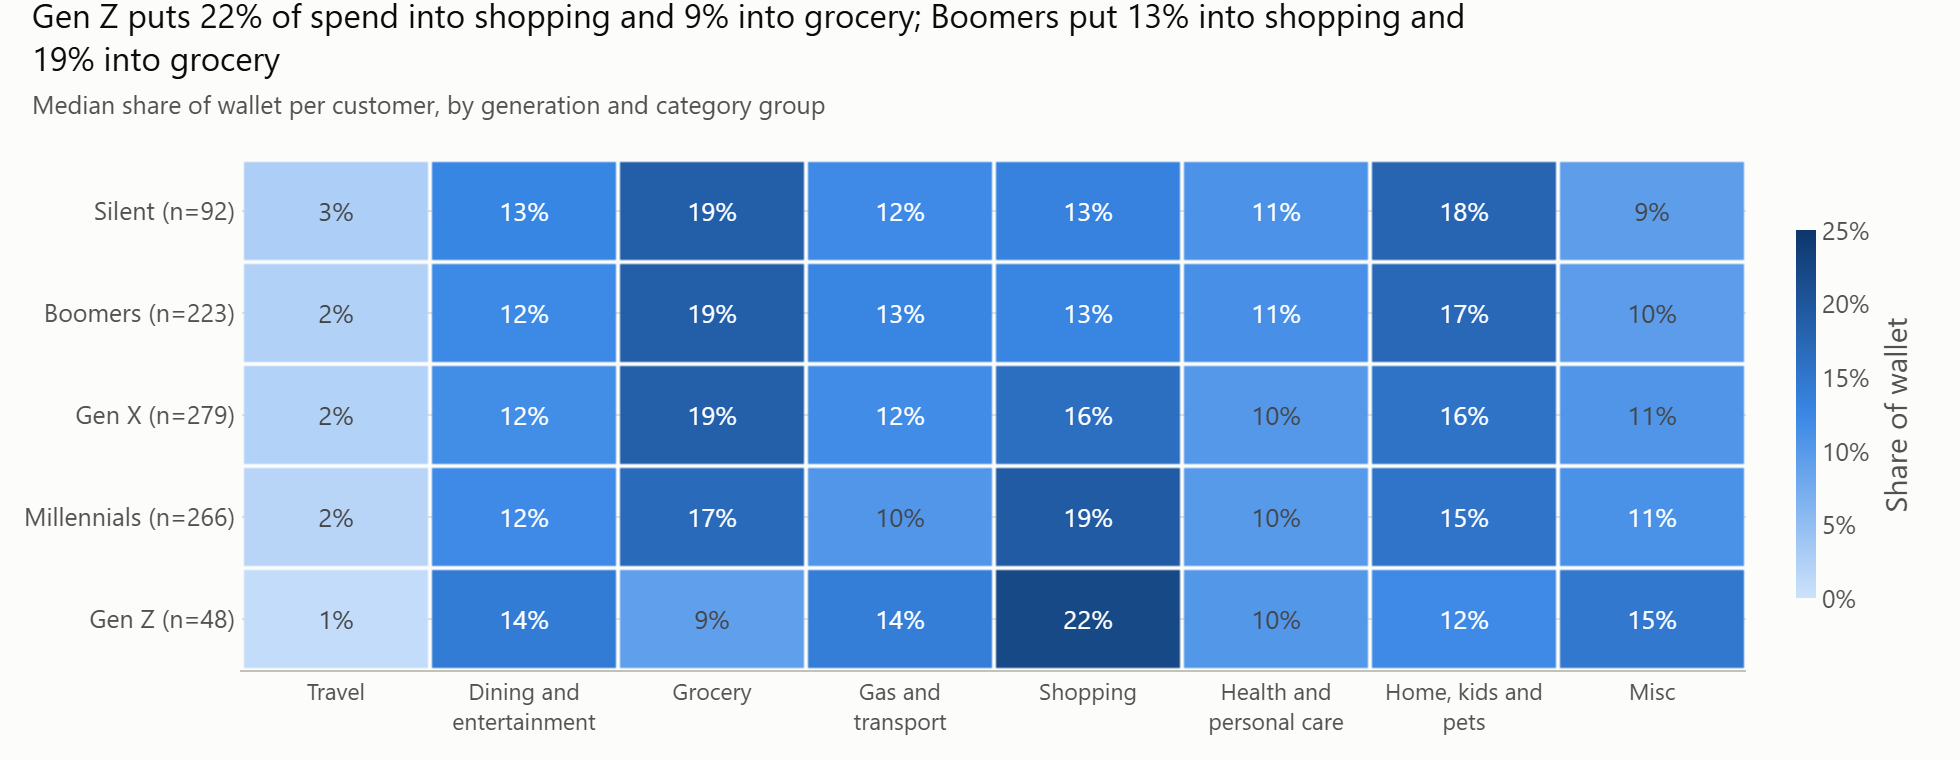

In [10]:
figs["wallet_heatmap"].show()

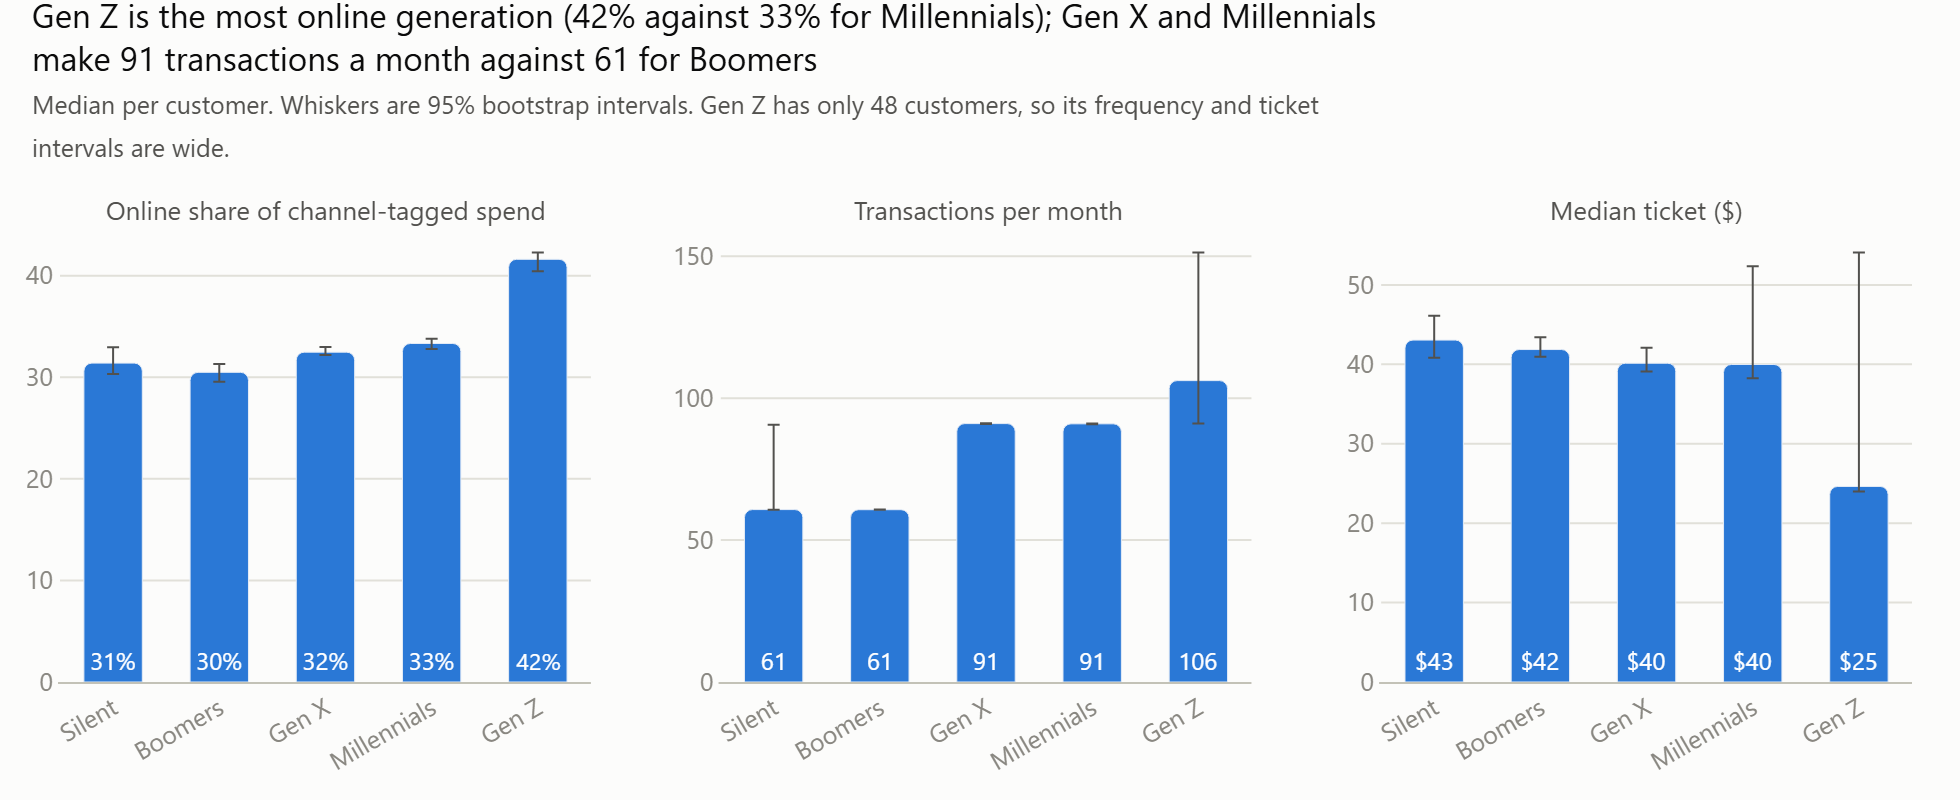

In [11]:
figs["generation_bars"].show()

### Are these generation effects, or the generator's age bands?

If generations mattered in their own right, behavior would change at the Pew cutoffs. It does not. It changes at
two other birth years.

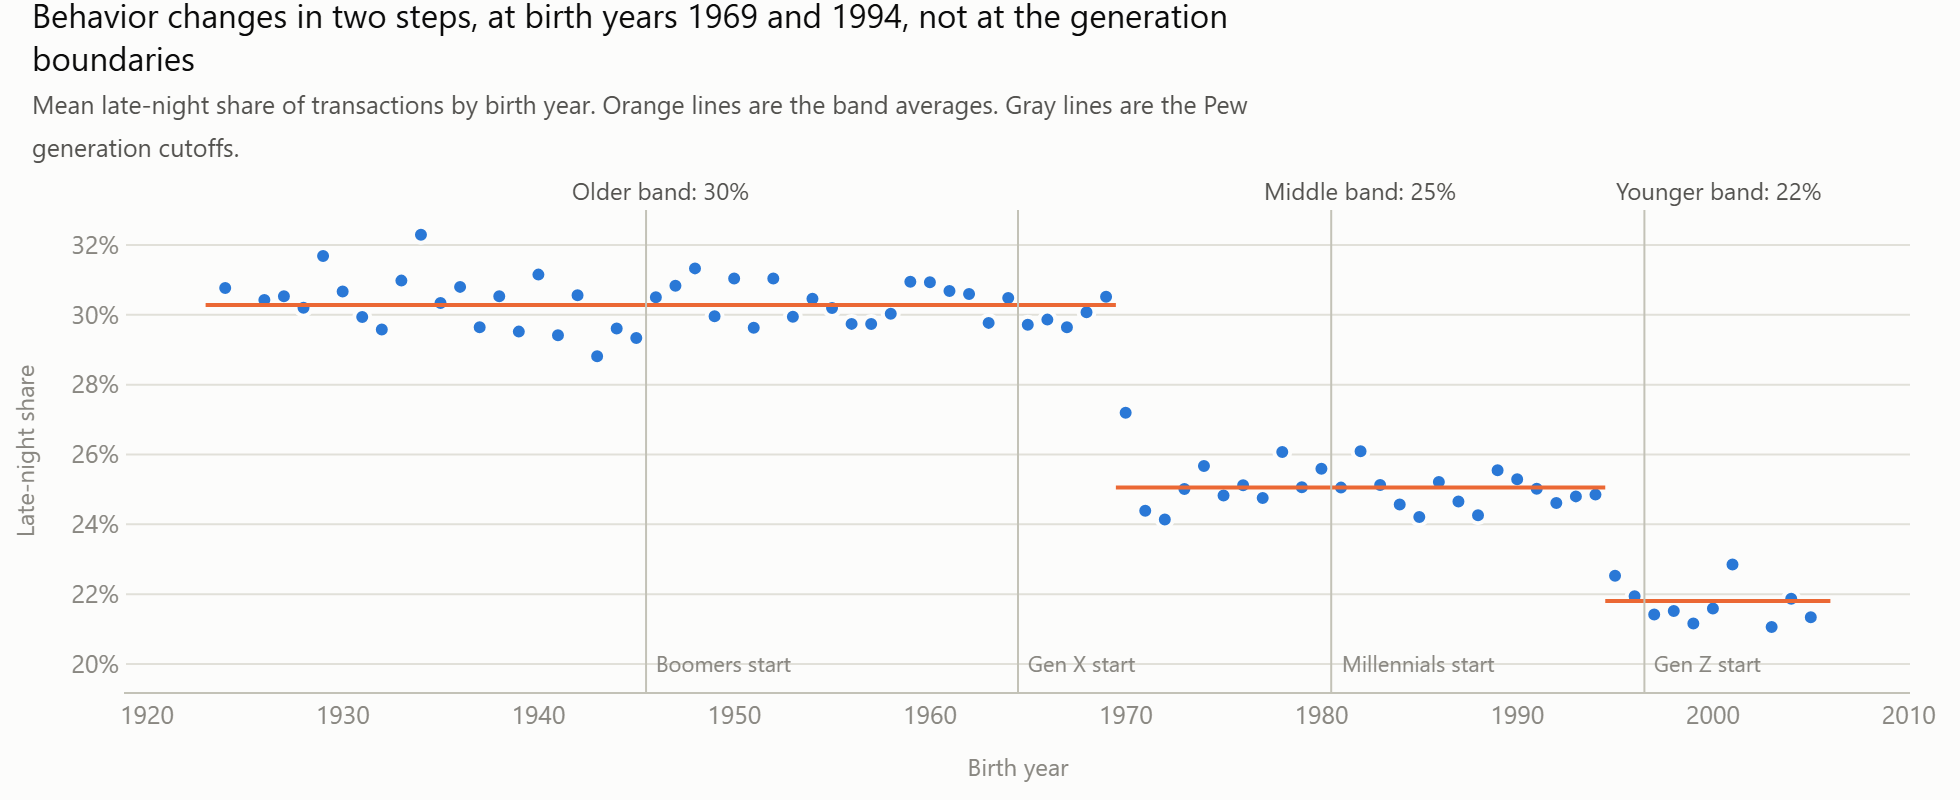

In [12]:
figs["birth_year_steps"].show()

In [13]:
a = d["artifact"]
display(pd.DataFrame(a["generation_by_band"]).T)
say(f"A three-leaf regression tree on birth year puts the steps at **{a['birth_year_cuts'][0]}** and "
    f"**{a['birth_year_cuts'][1]}**. Silent and Boomers sit in the same band. Gen X is split across two. "
    f"The test that settles it: compare generations **inside** one band. The median effect size falls from "
    f"{a['median_effect_by_generation']:.3f} to **{a['median_effect_within_age_band']:.3f}** "
    f"(largest {a['max_effect_within_age_band']:.3f}). The generational differences above are real in size, "
    f"but they are the generator's age bands seen through Pew labels.")

,Older band,Middle band,Younger band
Silent,92,0,0
Boomers,223,0,0
Gen X,87,192,0
Millennials,0,248,18
Gen Z,0,0,48


A three-leaf regression tree on birth year puts the steps at **1969** and **1994**. Silent and Boomers sit in the same band. Gen X is split across two. The test that settles it: compare generations **inside** one band. The median effect size falls from 0.085 to **0.003** (largest 0.007). The generational differences above are real in size, but they are the generator's age bands seen through Pew labels.

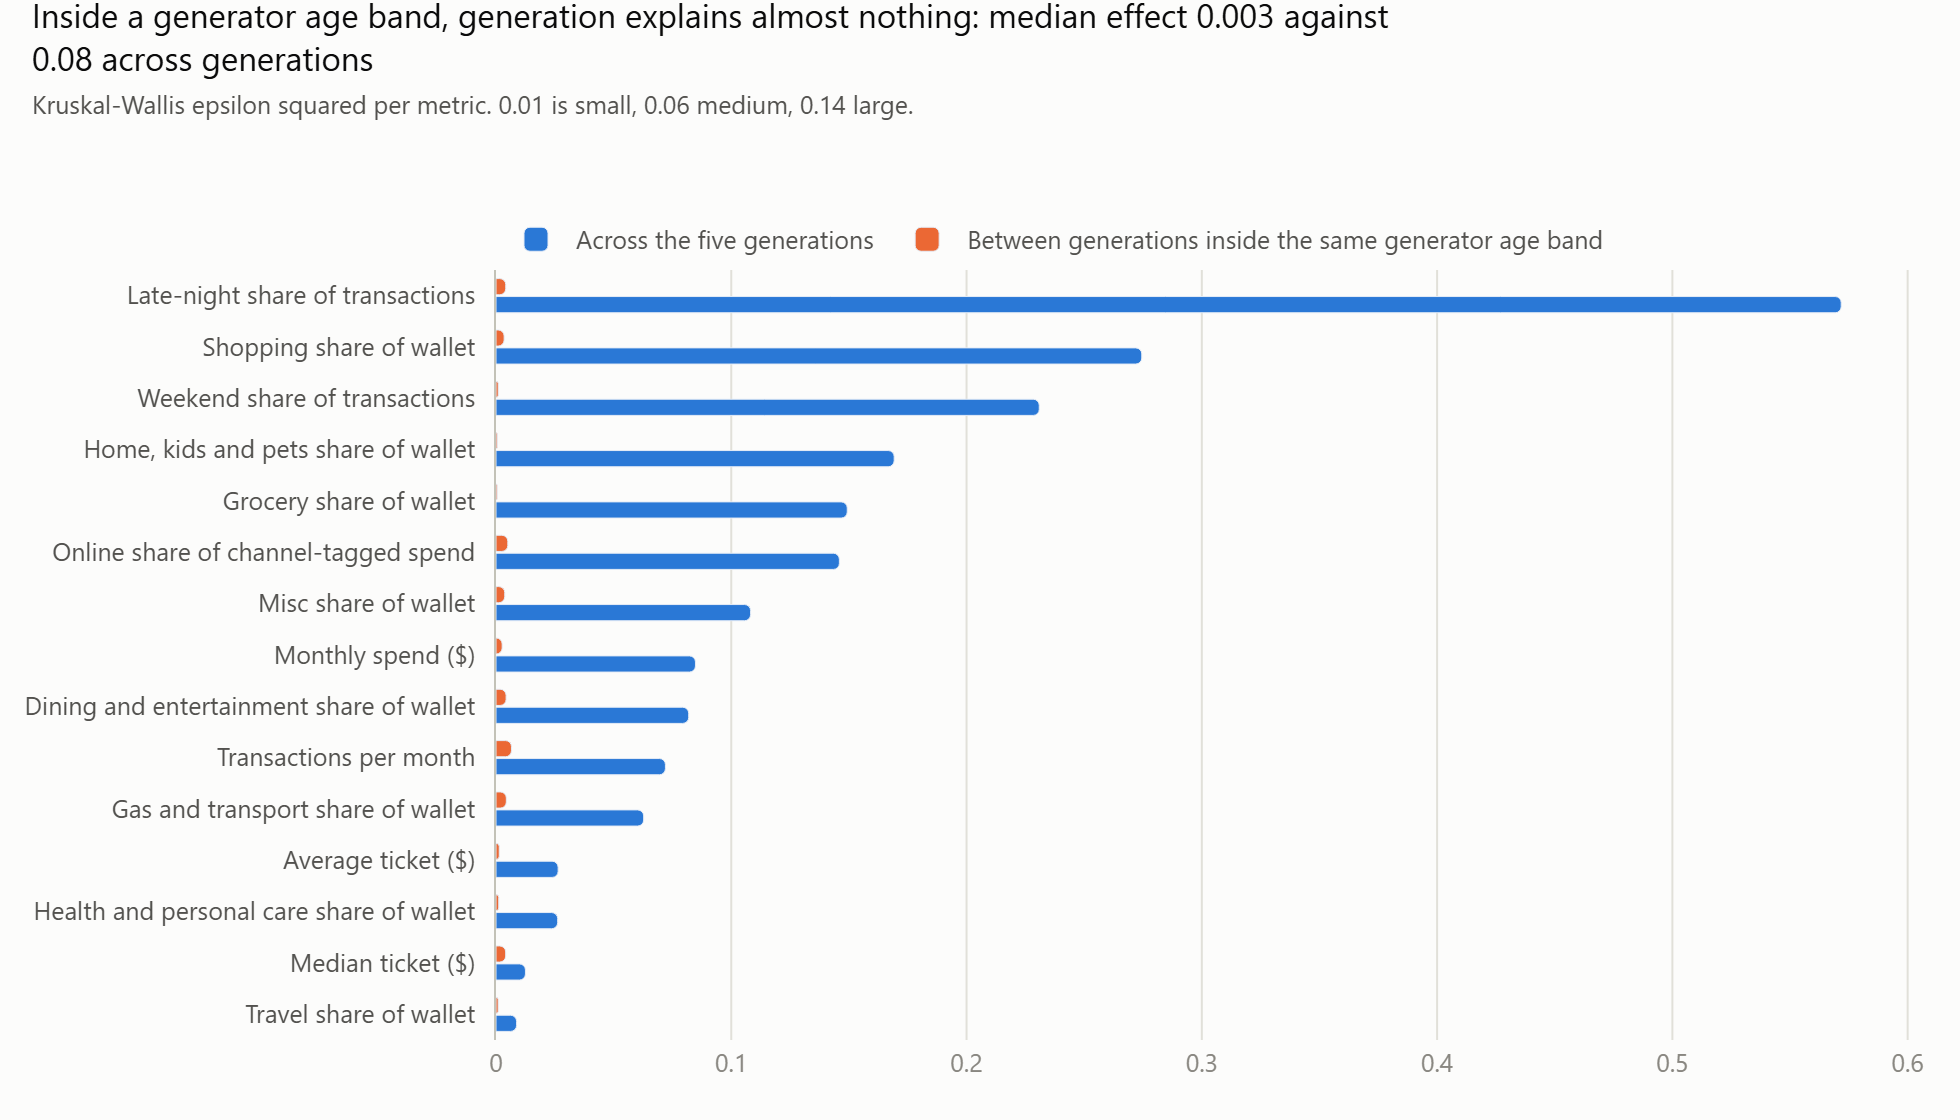

In [14]:
figs["effect_sizes"].show()

## 4. Behavior segments

K-means on 16 behavior features after `log1p` and standard scaling. Age, gender and city size are **not** inputs.
They are held back to test the result.

**Choosing k.** Four things are weighed: silhouette, the inertia elbow, stability under bootstrap resampling
(adjusted Rand index against the full-data labels, 100 resamples) and whether the segments tell different
business stories.

,k,inertia,silhouette,bootstrap_ari_mean,bootstrap_ari_p05,smallest_segment,gmm_bic,gmm_vs_kmeans_ari,inertia_drop_pct
0,3,"9,259.564",0.243,0.857,0.477,200,"15,111.511",0.479,NaN
1,4,"7,740.013",0.279,0.936,0.753,60,"14,585.635",0.738,0.164
2,5,"6,698.937",0.311,0.920,0.737,60,"14,607.116",0.954,0.135
3,6,"5,984.777",0.285,0.787,0.640,60,"14,608.833",0.829,0.107
4,7,"5,490.508",0.298,0.730,0.626,25,"14,427.879",0.841,0.083
5,8,"5,020.006",0.297,0.809,0.660,19,"14,194.588",0.524,0.086


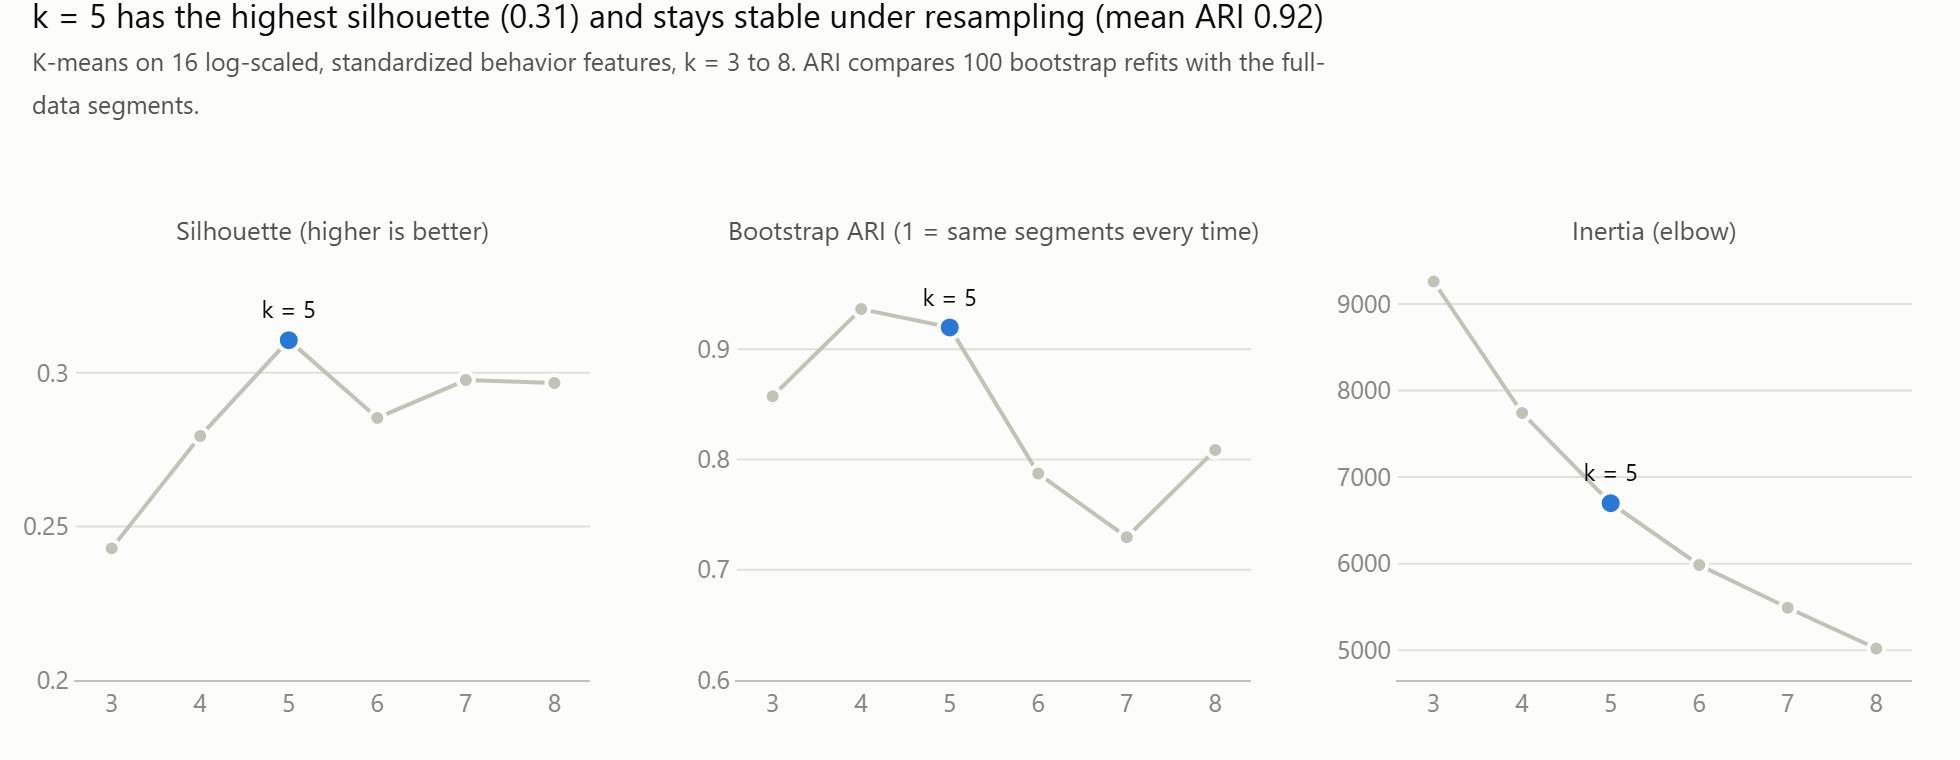

In [15]:
display(d["k_table"])
figs["k_selection"].show()

In [16]:
k = d["k_table"].set_index("k")
chosen = d["check"]["chosen_k"]
say(f"**k = {chosen}.** It has the highest silhouette ({k.loc[chosen, 'silhouette']:.3f}) and a mean bootstrap ARI of "
    f"{k.loc[chosen, 'bootstrap_ari_mean']:.2f} (5th percentile {k.loc[chosen, 'bootstrap_ari_p05']:.2f}). "
    f"k = 4 is slightly more stable ({k.loc[4, 'bootstrap_ari_mean']:.2f}) but merges travelers with high-spend "
    f"household shoppers, which are opposite targets for a travel credit. From k = 6 stability drops "
    f"({k.loc[6, 'bootstrap_ari_mean']:.2f}). Inertia has no sharp elbow. A Gaussian mixture with {chosen} components "
    f"gives nearly the same segments (ARI {k.loc[chosen, 'gmm_vs_kmeans_ari']:.2f} against K-means), so the result does "
    f"not depend on K-means' assumptions. A silhouette near {k.loc[chosen, 'silhouette']:.1f} is moderate: the segments "
    f"overlap at the edges.")

**k = 5.** It has the highest silhouette (0.311) and a mean bootstrap ARI of 0.92 (5th percentile 0.74). k = 4 is slightly more stable (0.94) but merges travelers with high-spend household shoppers, which are opposite targets for a travel credit. From k = 6 stability drops (0.79). Inertia has no sharp elbow. A Gaussian mixture with 5 components gives nearly the same segments (ARI 0.95 against K-means), so the result does not depend on K-means' assumptions. A silhouette near 0.3 is moderate: the segments overlap at the edges.

### Segment profile cards

In [17]:
cards = d["profiles"].set_index("segment_name")[["n_customers", "customer_share", "spend_share", "monthly_spend",
    "monthly_txns", "avg_ticket", "online_share", "median_age", "pct_female", "top_categories", "over_indexed"]]
display(cards.T)
display(d["profiles"].set_index("segment_name")[[f"gen_{g}" for g in config.GENERATIONS]].rename(columns=lambda c: c[4:]).style.format("{:.0%}"))

segment_name,Premium Household Shoppers,Big-Ticket Travelers,Digital Shoppers,Mainstream Everyday Spenders,Light Home and Dining Spenders
n_customers,114,102,60,438,194
customer_share,0.126,0.112,0.066,0.482,0.214
spend_share,0.209,0.132,0.073,0.447,0.140
monthly_spend,"9,510.280","6,698.923","6,303.712","5,305.719","3,735.774"
monthly_txns,108.050,71.986,108.213,90.236,57.239
avg_ticket,87.839,92.869,58.724,58.913,64.987
online_share,0.339,0.316,0.421,0.331,0.298
median_age,37.000,38.000,22.000,50.000,62.000
pct_female,1.000,0.010,0.533,0.505,0.474
top_categories,"Grocery | Shopping | Home, kids and pets",Travel | Shopping | Grocery,Shopping | Misc | Dining and entertainment,"Grocery | Home, kids and pets | Shopping","Home, kids and pets | Grocery | Dining and ent..."


,Silent,Boomers,Gen X,Millennials,Gen Z
segment_name,,,,,
Premium Household Shoppers,0%,0%,39%,61%,0%
Big-Ticket Travelers,0%,4%,40%,56%,0%
Digital Shoppers,0%,0%,0%,20%,80%
Mainstream Everyday Spenders,11%,27%,34%,28%,0%
Light Home and Dining Spenders,23%,53%,22%,3%,0%


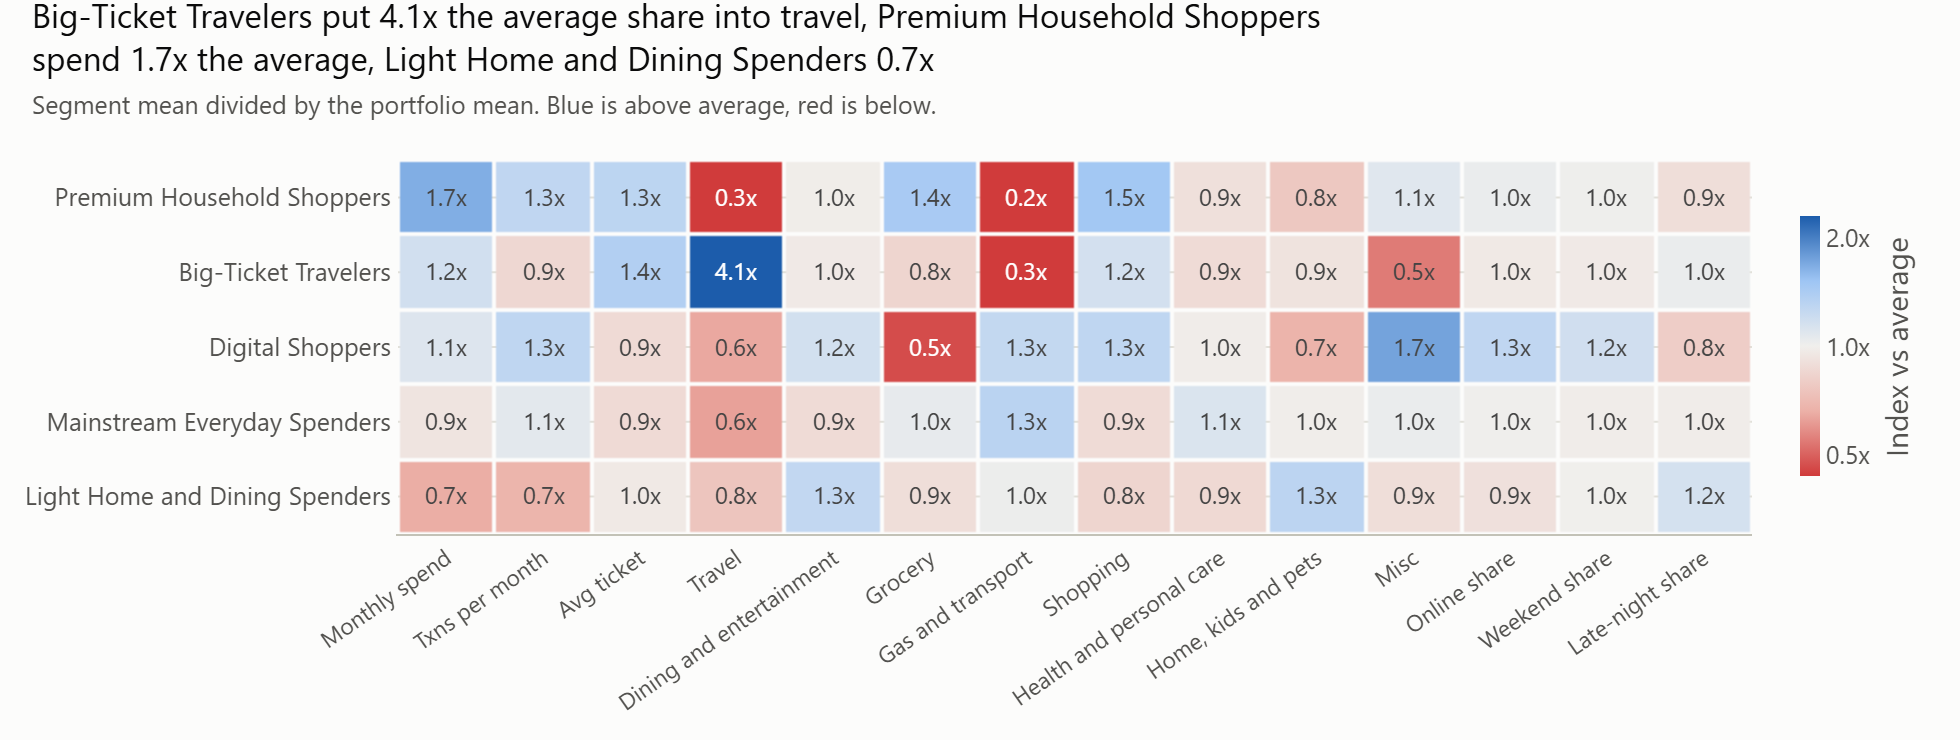

In [18]:
figs["segment_index_heatmap"].show()

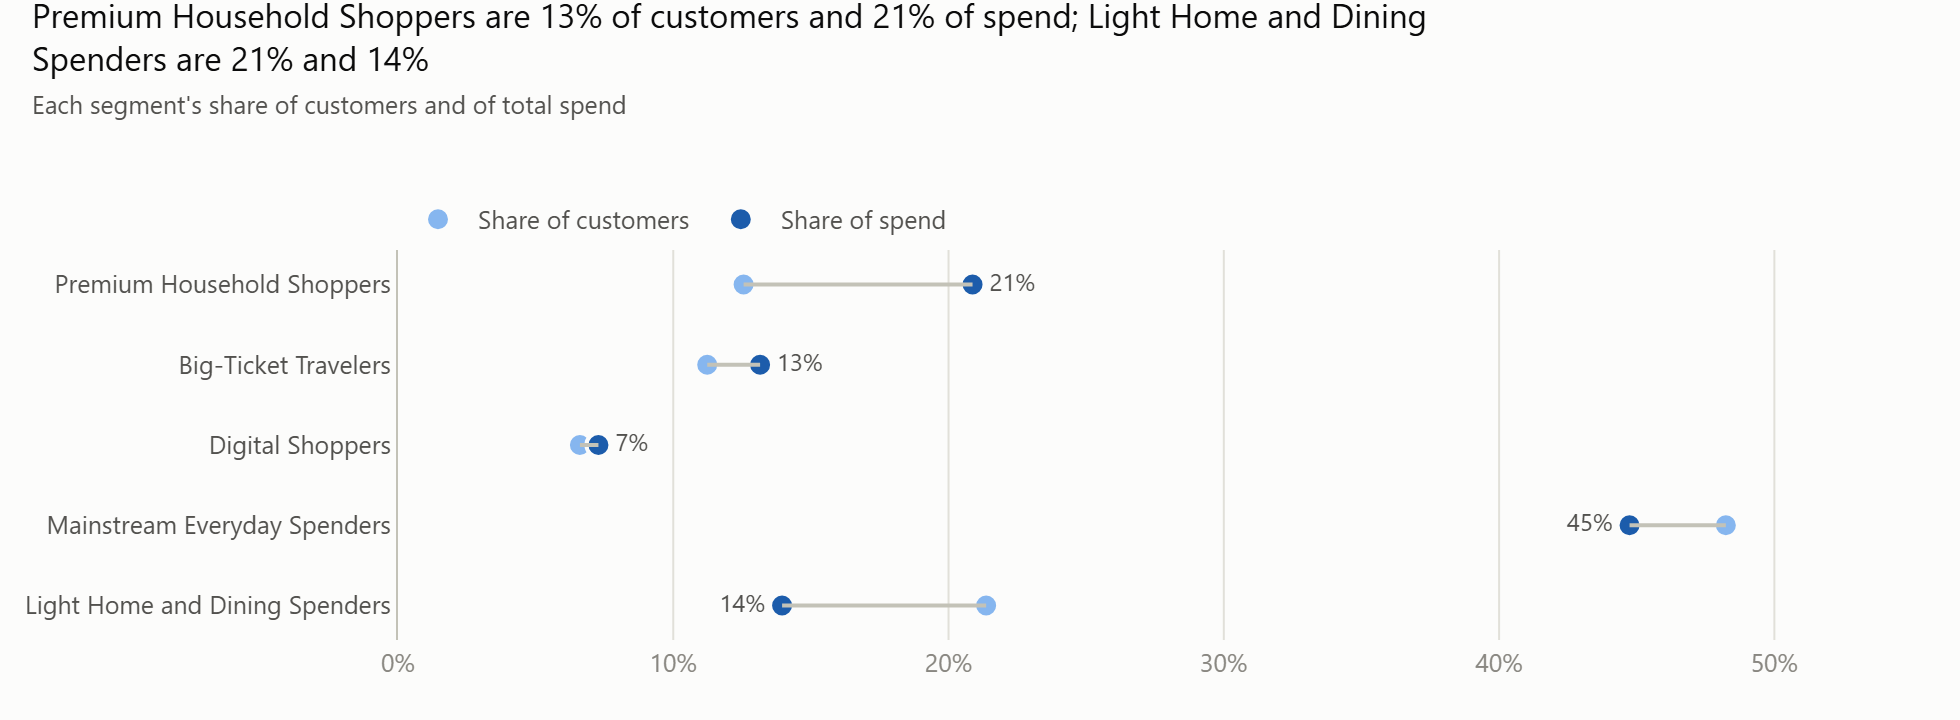

In [19]:
figs["size_vs_spend"].show()

### Do the segments just reproduce the generator's buckets?

In [20]:
c = d["check"]
display(pd.Series(c["cramers_v"], name="Cramer's V with segment").sort_values(ascending=False).to_frame())
display(pd.crosstab(f.segment_name, f.age_band), pd.crosstab(f.segment_name, f.gender))
say(f"**Mostly yes.** A random forest that sees only birth year, gender and city population predicts the behavior "
    f"segment for **{c['demographics_only_accuracy']:.1%}** of customers (5-fold cross-validation). Always guessing the "
    f"largest segment gets {c['majority_baseline_accuracy']:.1%}. The clustering never saw those three variables, so it "
    f"has rediscovered the generator's customer profiles. In a real portfolio this would be a warning that the "
    f"behavior segments add little beyond a demographic cut.")

,Cramer's V with segment
inferred_age_band,0.810
generation,0.523
gender,0.480
city_size_band,0.427
transactions_per_day_tier,0.237


age_band,Middle band,Older band,Younger band
segment_name,,,
Big-Ticket Travelers,97,5,0
Digital Shoppers,0,0,60
Light Home and Dining Spenders,10,183,1
Mainstream Everyday Spenders,219,214,5
Premium Household Shoppers,114,0,0


gender,F,M
segment_name,,
Big-Ticket Travelers,1,101
Digital Shoppers,32,28
Light Home and Dining Spenders,92,102
Mainstream Everyday Spenders,221,217
Premium Household Shoppers,114,0


**Mostly yes.** A random forest that sees only birth year, gender and city population predicts the behavior segment for **96.3%** of customers (5-fold cross-validation). Always guessing the largest segment gets 48.2%. The clustering never saw those three variables, so it has rediscovered the generator's customer profiles. In a real portfolio this would be a warning that the behavior segments add little beyond a demographic cut.

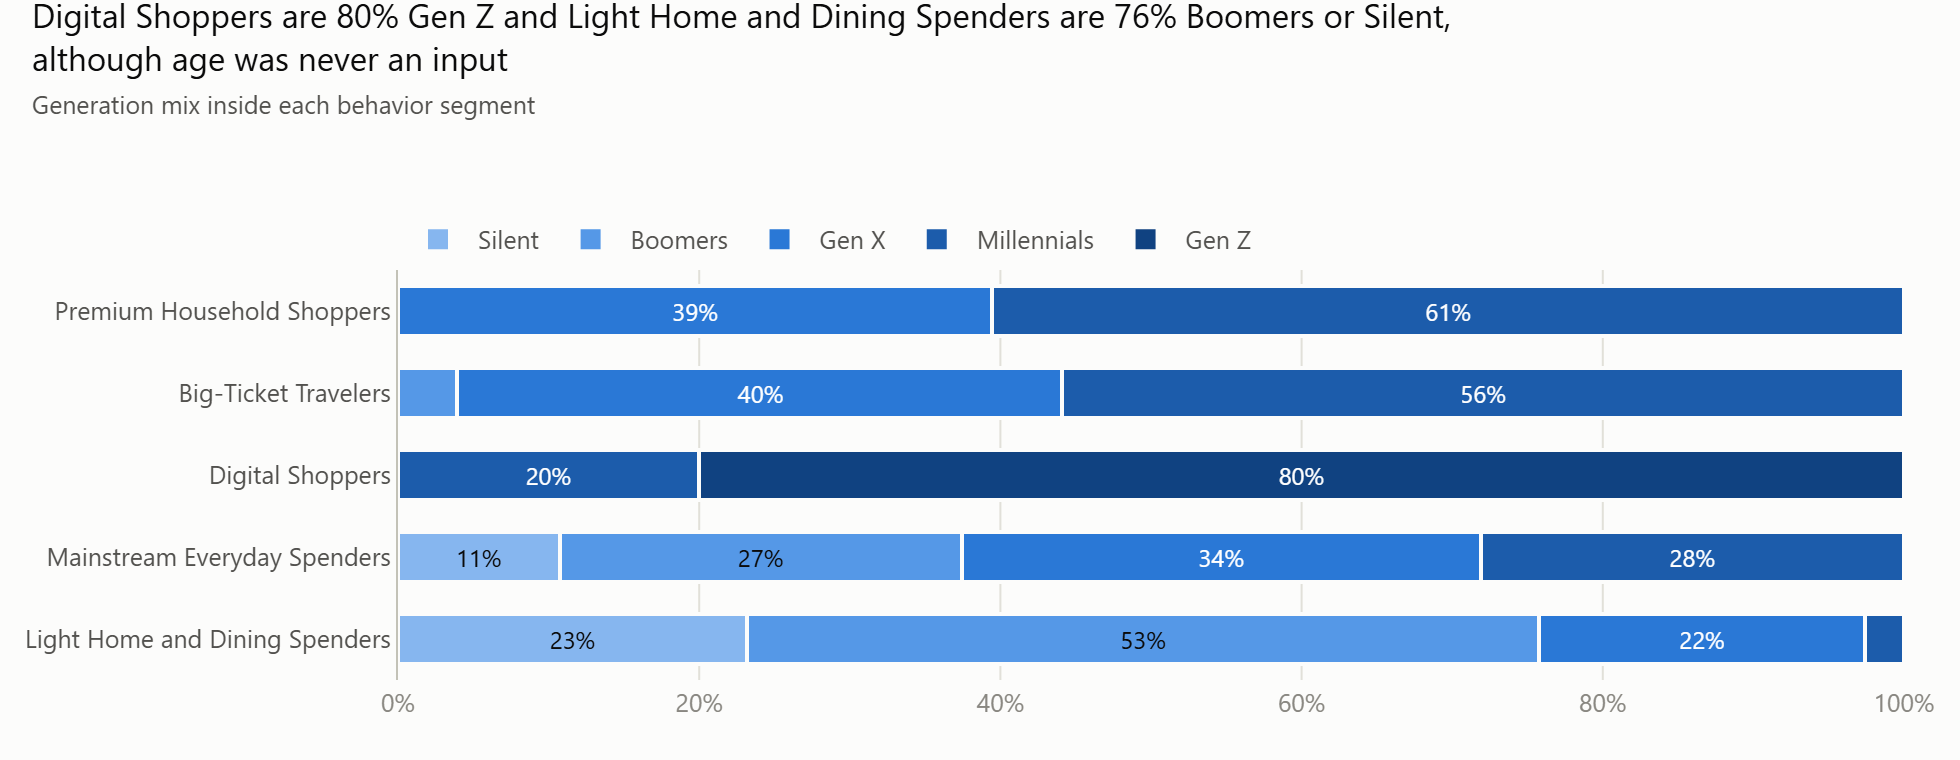

In [21]:
figs["generation_mix"].show()

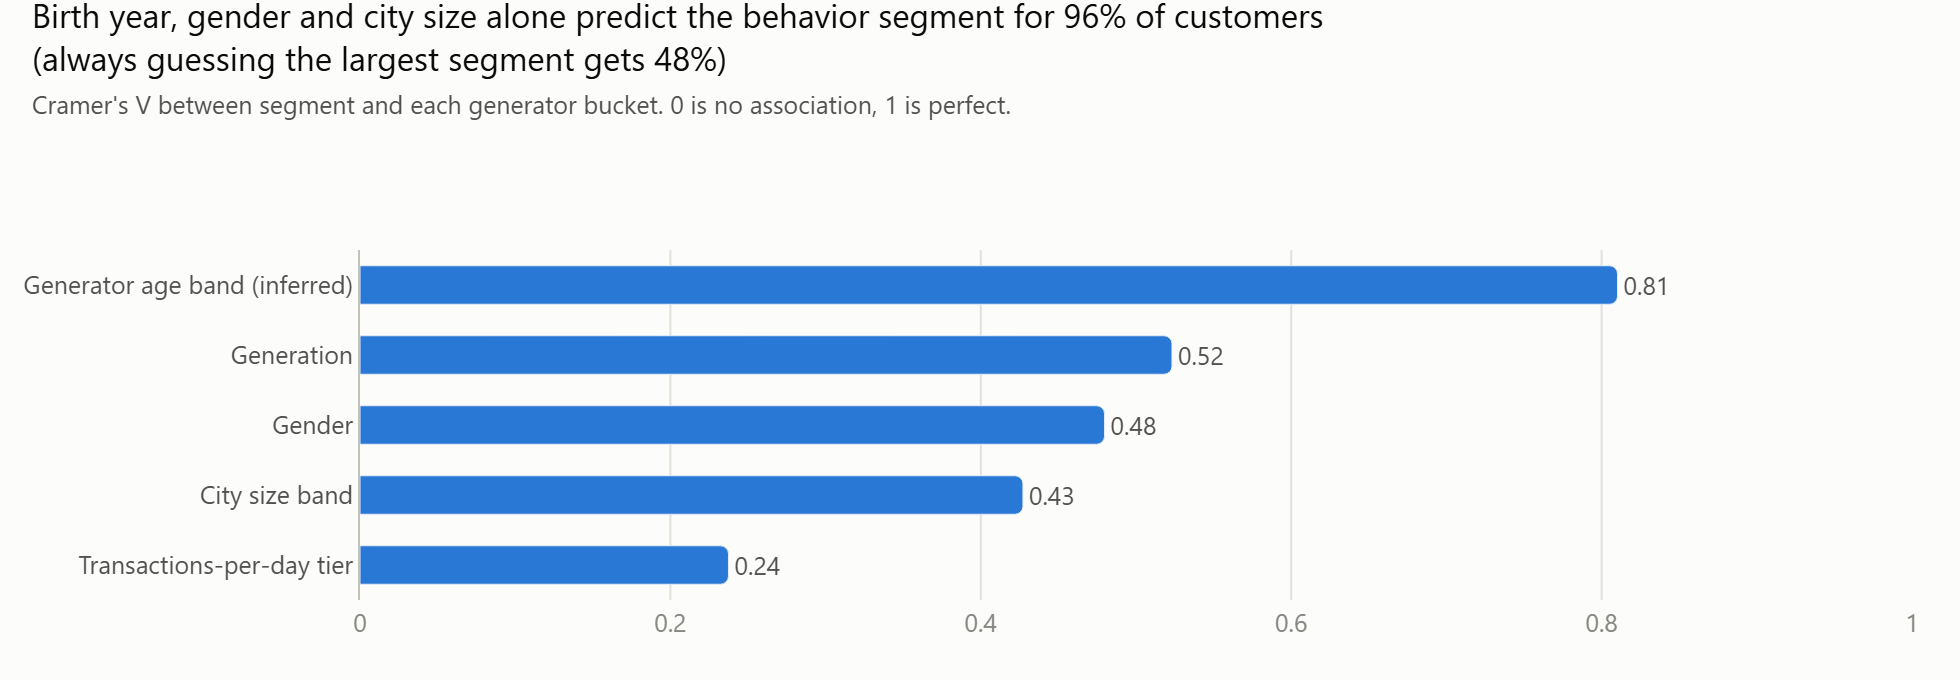

In [22]:
figs["generator_check"].show()

## 5. Who should get which benefit

Two hypothetical benefits: a monthly dining credit and an annual travel credit.

`score = engagement x headroom x value`

- **engagement**: share of redemption periods in which the segment's customers already make a qualifying purchase
  (months with any dining transaction; years with a travel purchase of $100 or more)
- **headroom**: 1 minus the customer's category share of wallet divided by the 90th percentile share across all
  customers, clipped to 0..1, averaged over the segment
- **value**: segment mean monthly spend divided by the highest segment's mean monthly spend

,benefit_label,rank,segment_name,n_customers,engagement,headroom,value,score,category_share_of_wallet,category_monthly_spend
0,Monthly dining credit,1,Premium Household Shoppers,114,0.972,0.496,1.000,0.482,0.049,463.358
1,Monthly dining credit,2,Digital Shoppers,60,0.984,0.547,0.663,0.357,0.044,268.722
2,Monthly dining credit,3,Big-Ticket Travelers,102,0.959,0.462,0.704,0.312,0.052,349.871
3,Monthly dining credit,4,Mainstream Everyday Spenders,438,0.955,0.535,0.558,0.285,0.045,234.749
4,Monthly dining credit,5,Light Home and Dining Spenders,194,0.955,0.064,0.393,0.024,0.095,357.129
5,Annual travel credit,1,Premium Household Shoppers,114,0.561,0.924,1.000,0.518,0.014,147.596
6,Annual travel credit,2,Mainstream Everyday Spenders,438,0.603,0.825,0.558,0.278,0.031,171.971
7,Annual travel credit,3,Digital Shoppers,60,0.467,0.837,0.663,0.259,0.032,181.152
8,Annual travel credit,4,Light Home and Dining Spenders,194,0.582,0.790,0.393,0.181,0.037,155.480
9,Annual travel credit,5,Big-Ticket Travelers,102,0.975,0.011,0.704,0.007,0.204,"1,339.890"


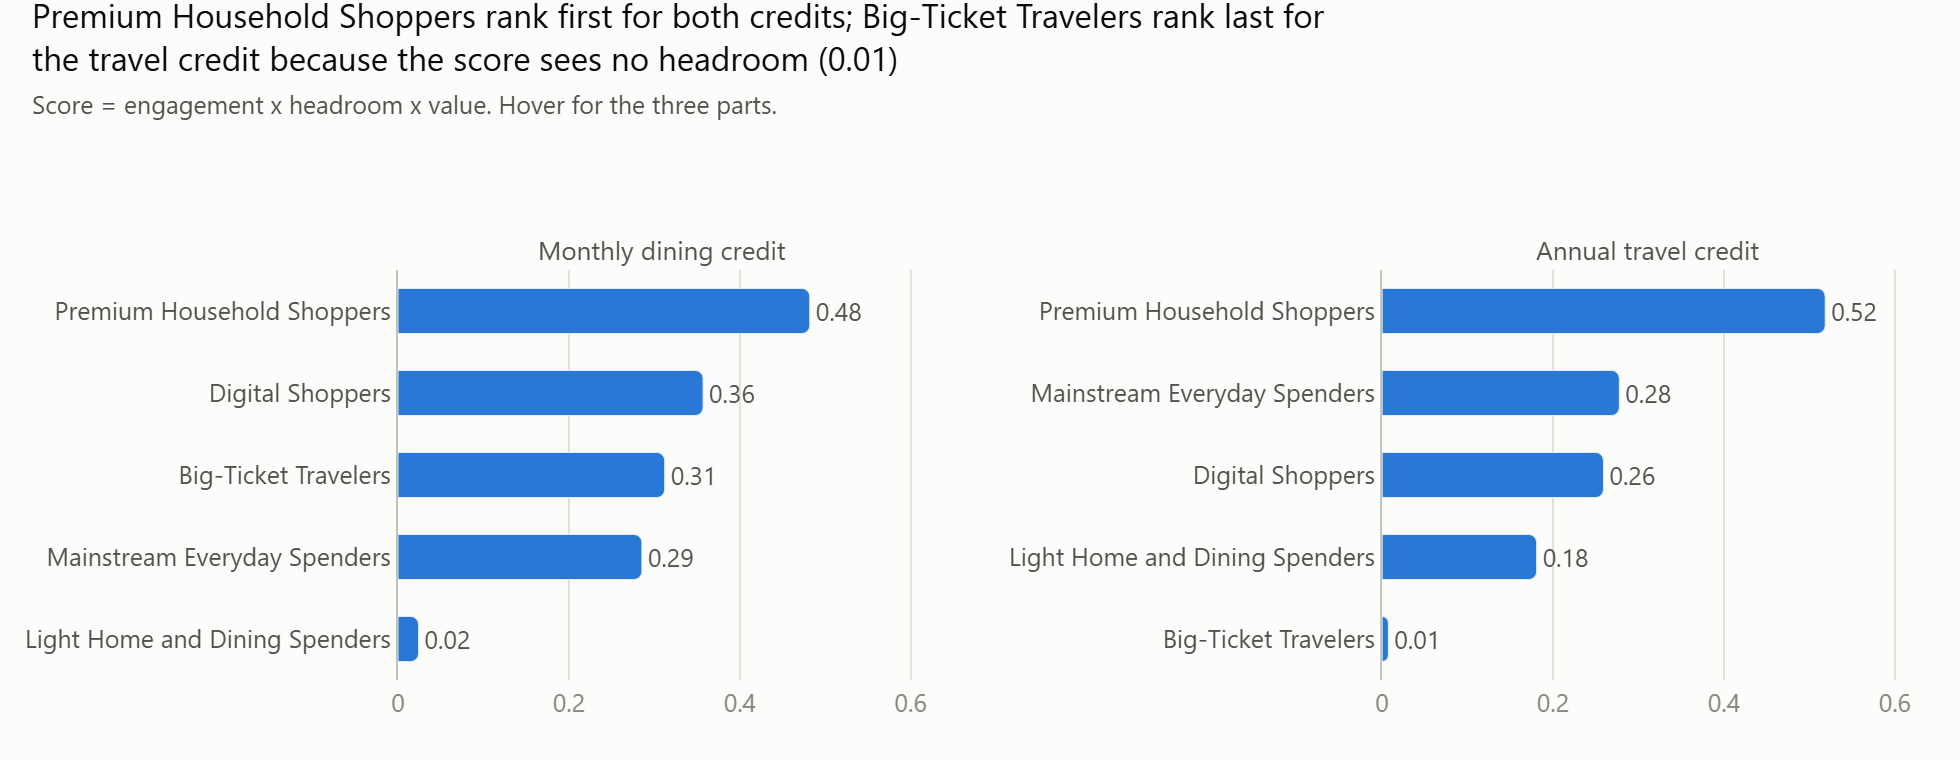

In [23]:
display(d["targeting"][["benefit_label", "rank", "segment_name", "n_customers", "engagement", "headroom", "value", "score",
                        "category_share_of_wallet", "category_monthly_spend"]])
figs["targeting_scores"].show()

In [24]:
say("**Weaknesses of this score**\n\n" + "\n".join(f"- {w}" for w in WEAKNESSES))

**Weaknesses of this score**

- Multiplying three terms weights them equally. Nothing in the data says they should be equal.
- Headroom treats a low category share as room to grow. It could equally mean no interest in the category.
- Engagement and headroom pull in opposite directions, so the score favors the middle and gives the heaviest category users a low score. It ranks segments for growth. It says nothing about retention value.
- Value is total card spend, not profit. It ignores credit cost, redemption rate, interchange and credit risk.
- It is a segment average. Customers inside a segment vary, and a customer-level response model would beat it.
- It is built from observed spend, not from observed response to an offer. Only a randomized test can tell whether the ranking predicts incremental spend.
- The 90th percentile benchmark is a choice. A different benchmark shifts headroom for every segment.

## 6. Triggers

Three rules, defined in `sql/06_triggers.sql` and scored for every customer in every month.

,trigger,rule
0,Travel drop,"Travel spend over the last 3 months is more than 50% below the 3 months before, after allowing for the portfolio-wide change, from a base of at least $200."
1,First travel,"First-ever travel transaction, after at least 3 months on the card with no travel."
2,Dining cooling,"Dining transaction count down two months in a row relative to the portfolio, from a base of at least 4 a month, with a total fall of 50% or more."


,trigger_name,fires,customers,spend_at_stake,median_stake_per_fire,pct_customers_ever_firing,avg_fires_per_month
0,travel_drop,1029,647,"2,692,397.221","1,467.572",0.713,42.875
1,first_travel,26,26,"2,147.280",7.845,0.029,1.083
2,dining_cooling,1256,721,"394,888.783",276.691,0.794,52.333


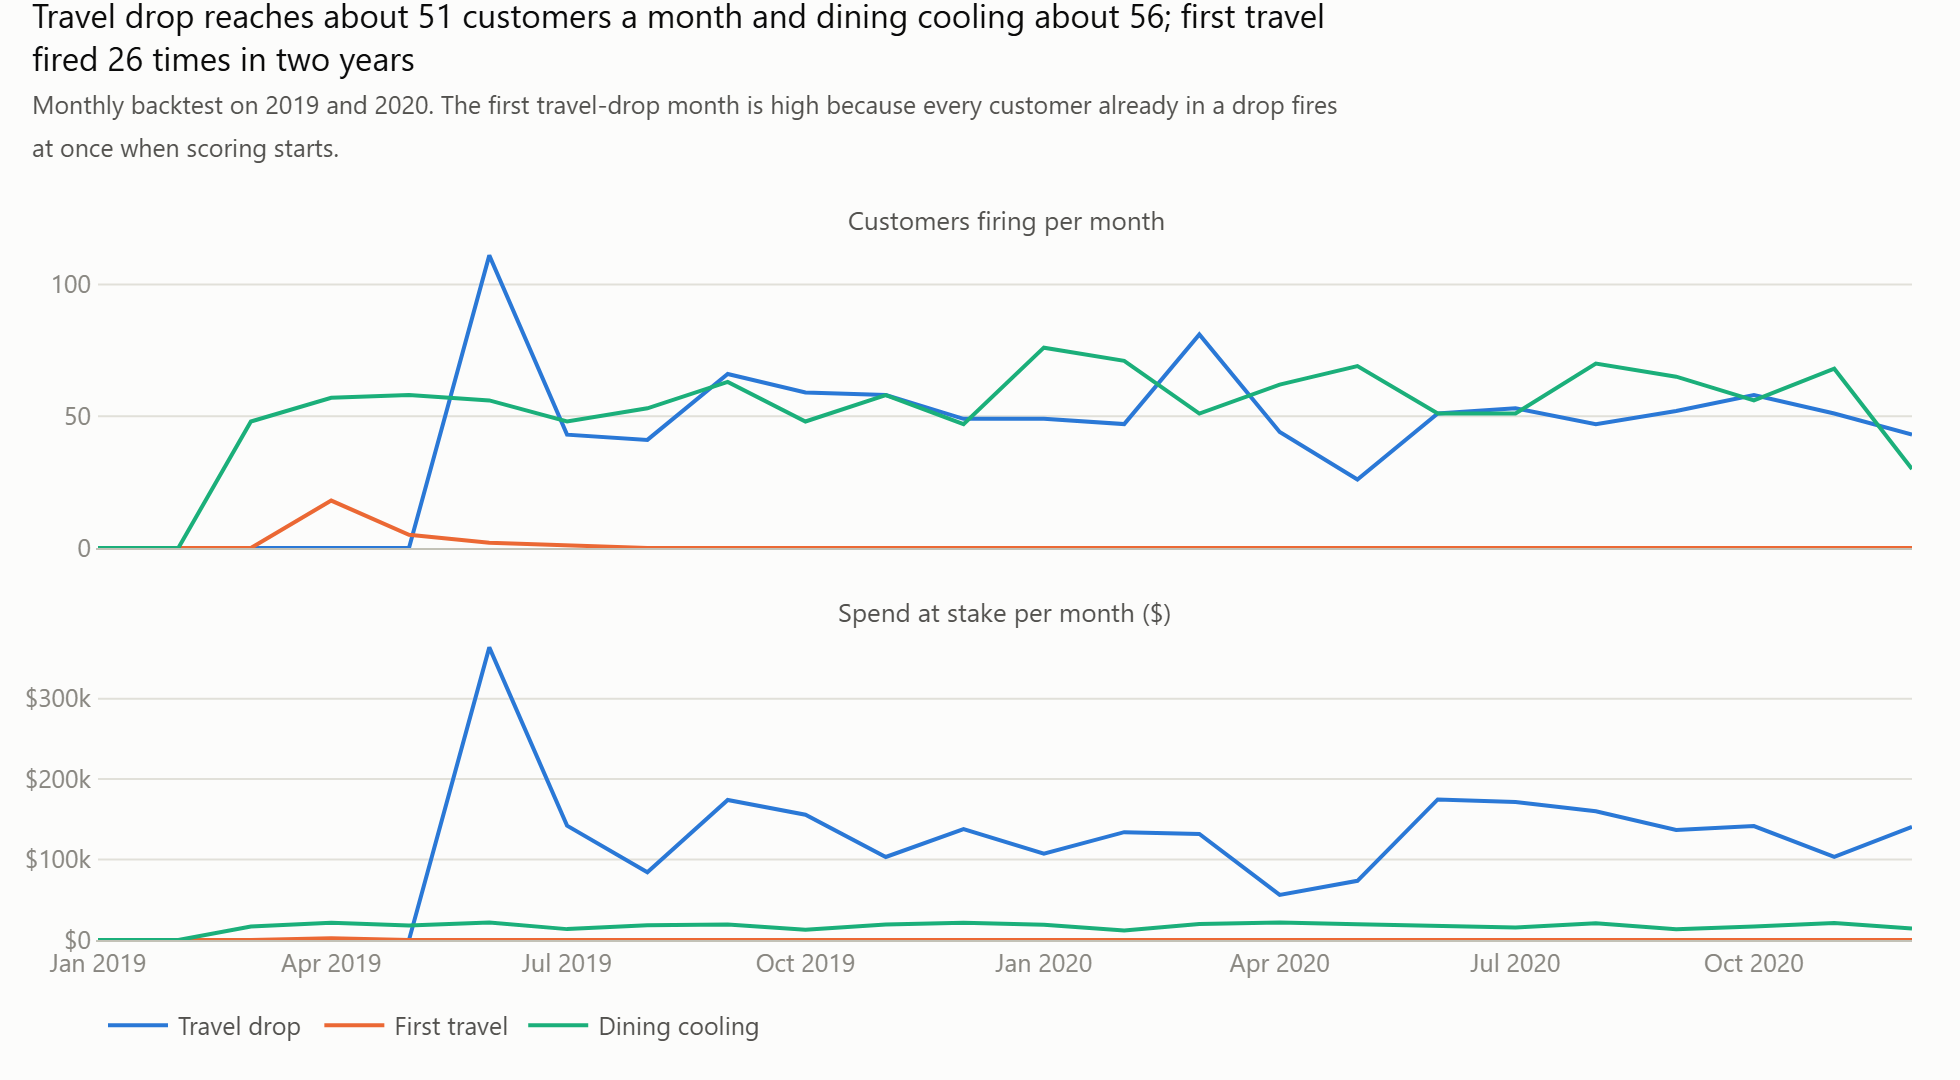

In [25]:
plays = pd.DataFrame(playbook.trigger_plays(d))
with pd.option_context("display.max_colwidth", None):
    display(plays[["trigger", "rule"]])
display(d["trig_summary"])
figs["trigger_monthly"].show()

### Shared seasonality would break a naive rule

Comparing a customer only with their own past makes the whole portfolio look like it is declining after December.
The rules therefore measure each customer against what the portfolio did over the same months.

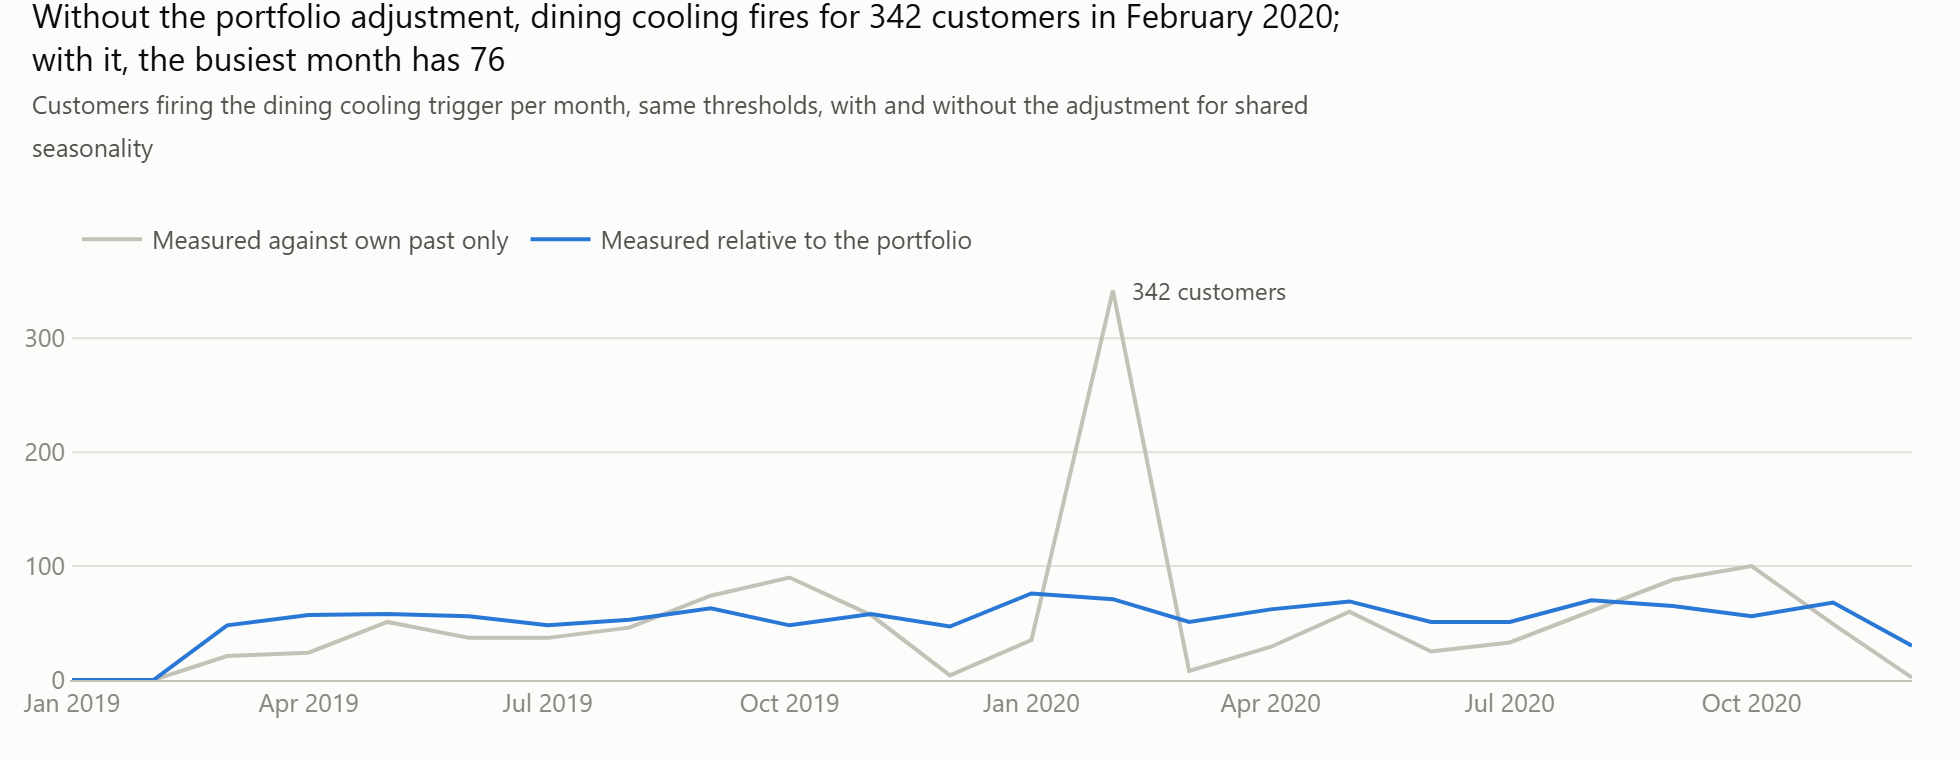

,variant,trigger_name,fires,customers,share_of_fires_in_jan_to_mar,peak_month_fires
0,"Naive rule (no portfolio adjustment, no floors...",dining_cooling,2003,835,0.256,385
1,"Naive rule (no portfolio adjustment, no floors...",travel_drop,4667,878,0.187,434
2,Default without portfolio adjustment,dining_cooling,1272,734,0.319,342
3,Default without portfolio adjustment,travel_drop,1035,654,0.193,109
4,Default,dining_cooling,1256,721,0.196,76
5,Default,first_travel,26,26,0.000,18
6,Default,travel_drop,1029,647,0.172,111
7,Travel base $500,travel_drop,832,568,0.169,87
8,"Travel base $1,000",travel_drop,655,487,0.159,70
9,Dining base 6 transactions,dining_cooling,902,571,0.208,63


In [26]:
figs["seasonality_adjustment"].show()
d["trig_sensitivity"]

### Overlap between triggers

In [27]:
d["trig_overlap"]

,trigger_a,trigger_b,same_month_both,same_month_share_of_smaller,customers_ever_both,customers_ever_either,customer_jaccard
0,travel_drop,first_travel,0,0.000,13,660,0.020
1,travel_drop,dining_cooling,64,0.062,509,859,0.593
2,first_travel,dining_cooling,3,0.115,17,730,0.023


### Are the triggers finding real change?

Two checks. First, a placebo: remove seasonality, shuffle each customer's months into random order, and run the
same rules. Shuffling keeps each customer's level and noise but destroys any sustained decline. Second, a follow-up:
what do fired customers do next, with no offer sent?

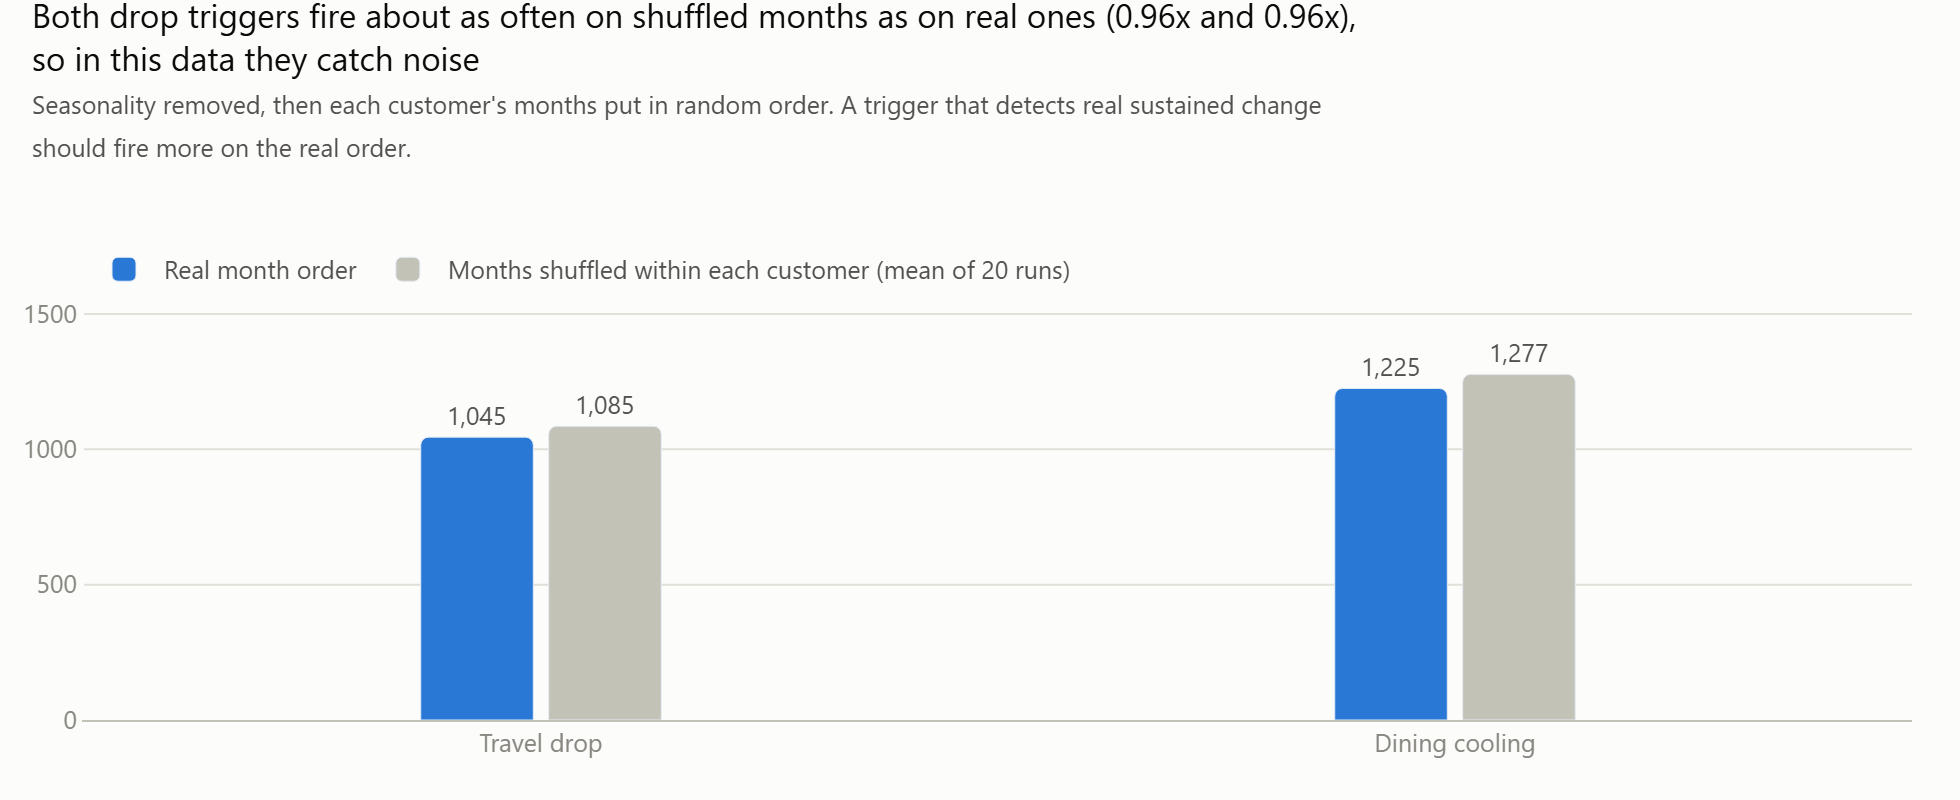

,trigger_name,actual_fires,placebo_fires_mean,placebo_fires_min,placebo_fires_max,actual_to_placebo_ratio
0,travel_drop,1045,"1,085.300",1068,1111,0.963
1,dining_cooling,1225,"1,277.100",1224,1315,0.959


In [28]:
figs["placebo"].show()
d["trig_placebo"]

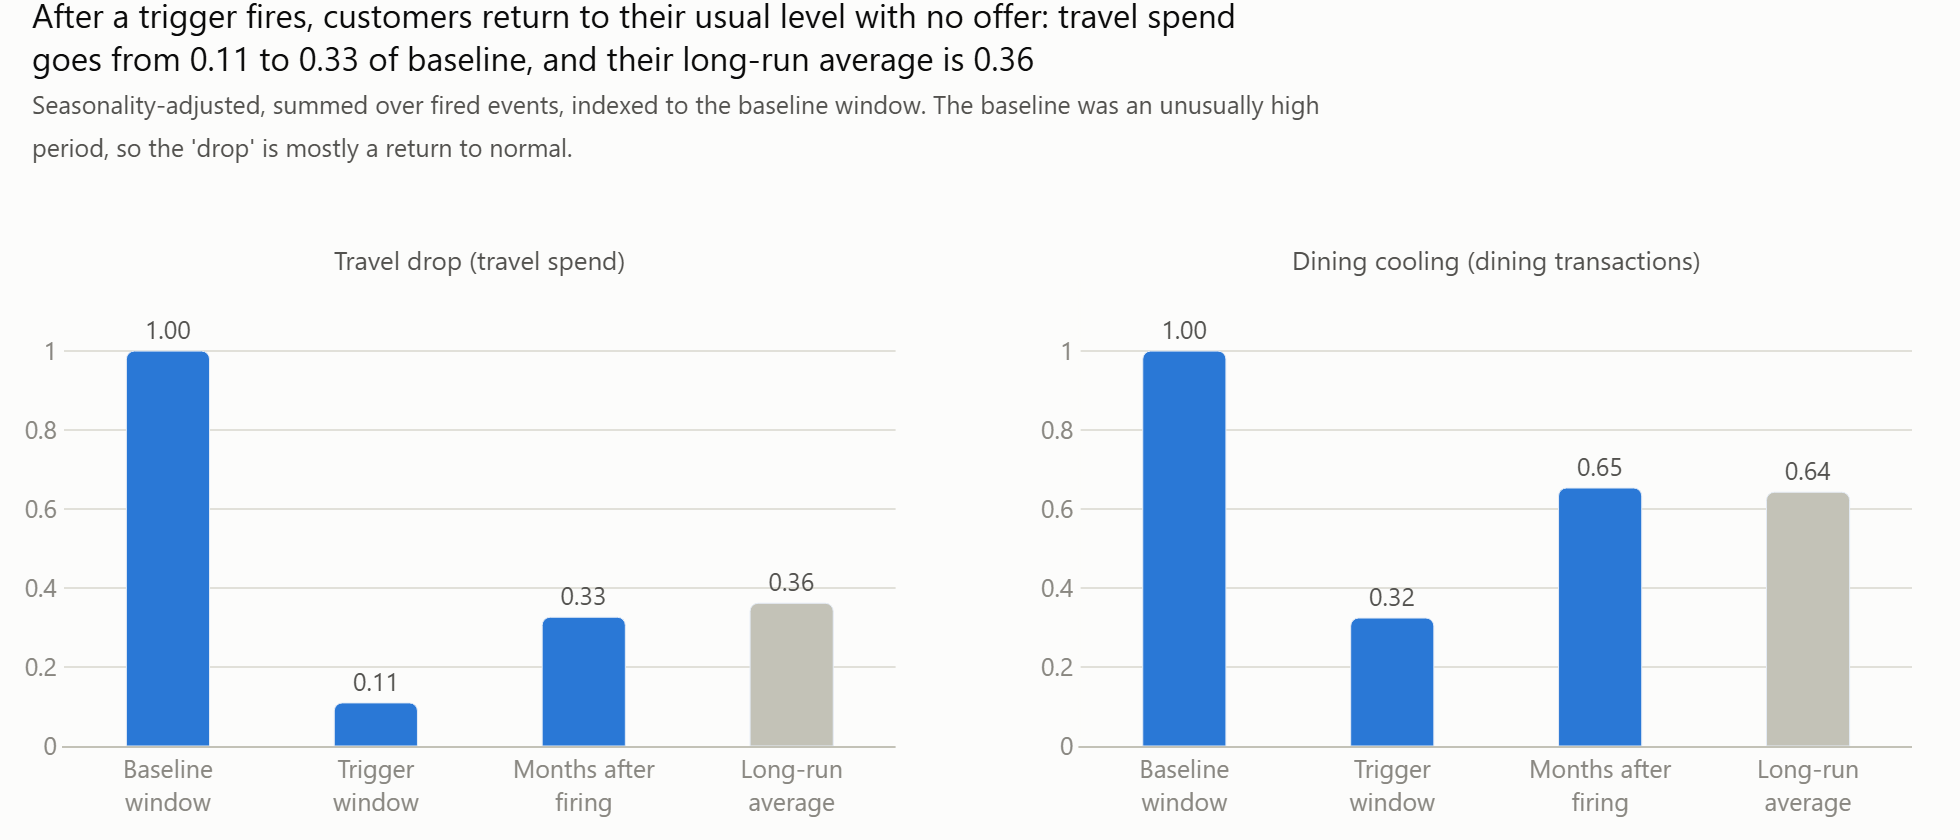

,scope,trigger_name,events_with_follow_up,baseline_index,trigger_period_index,follow_up_index,long_run_index,share_of_drop_recovered_unaided
0,All customers,travel_drop,877,1.000,0.109,0.326,0.361,0.244
1,All customers,dining_cooling,1158,1.000,0.324,0.653,0.643,0.487
2,Big-Ticket Travelers only,travel_drop,114,1.000,0.298,0.595,0.600,0.423
3,Big-Ticket Travelers only,dining_cooling,134,1.000,0.315,0.637,0.636,0.470


In [29]:
figs["follow_up"].show()
d["trig_follow_up"]

In [30]:
p = d["trig_placebo"].set_index("trigger_name").actual_to_placebo_ratio
fu = d["trig_follow_up"].query("scope == 'All customers'").set_index("trigger_name")
say(f"**Not in this data.** The drop triggers fire {p['travel_drop']:.2f}x and {p['dining_cooling']:.2f}x as often on the "
    f"real month order as on shuffled months, which is no difference. The generator has no customers whose behavior "
    f"actually shifts. The follow-up shows why: the baseline window was an unusually high period "
    f"(the long-run average is {fu.loc['travel_drop', 'long_run_index']:.2f} of baseline for travel and "
    f"{fu.loc['dining_cooling', 'long_run_index']:.2f} for dining), and after firing customers return to that usual "
    f"level on their own ({fu.loc['travel_drop', 'follow_up_index']:.2f} and {fu.loc['dining_cooling', 'follow_up_index']:.2f}). "
    f"This is regression to the mean. The backtest validates volume and mechanics. It cannot validate usefulness.")

**Not in this data.** The drop triggers fire 0.96x and 0.96x as often on the real month order as on shuffled months, which is no difference. The generator has no customers whose behavior actually shifts. The follow-up shows why: the baseline window was an unusually high period (the long-run average is 0.36 of baseline for travel and 0.64 for dining), and after firing customers return to that usual level on their own (0.33 and 0.65). This is regression to the mean. The backtest validates volume and mechanics. It cannot validate usefulness.

### Offer, channel, success metric and holdout

Because fired customers recover on their own, a before-and-after comparison would credit the offer with that
recovery. Each trigger therefore gets a randomized 10% holdout.

In [31]:
with pd.option_context("display.max_colwidth", None):
    display(plays[["trigger", "offer", "channel", "success_metric"]])
say(f"**Design.** {playbook.HOLDOUT_DESIGN} Randomize the first time a customer fires, keep them in that arm for "
    f"later fires, and stratify by segment.")
d["trig_holdout"]

,trigger,offer,channel,success_metric
0,Travel drop,Bonus points or a statement credit on the next travel booking made within 60 days.,"Email plus an in-app message. One contact, then silence for the cooldown period.",Travel spend per customer in the 3 months after the trigger fires.
1,First travel,Introduce the annual travel credit and add extra points on travel for 90 days.,"App push within two days of the purchase, followed by one email.","Share of customers who make a second travel purchase within 90 days, and travel spend over the same 3 months."
2,Dining cooling,"Reminder of the monthly dining credit, or a one-time dining bonus for customers without it.","App push or email early in the following month, when the monthly credit resets.",Dining transactions and dining spend per customer in the 3 months after the trigger fires.


**Design.** Each month, hold back a random 10% of the customers who fire and send them nothing. Compare treated with holdout on the success metric. Never compare before with after, because customers drift back to their usual level on their own. Randomize the first time a customer fires, keep them in that arm for later fires, and stratify by segment.

,trigger_name,fires_per_year,treated,holdout,outcome,outcome_mean,outcome_sd,min_detectable_lift_abs,min_detectable_lift_pct,fires_needed_for_10pct_lift
0,travel_drop,602,542,60,travel_spend in the 3 months after firing,981.078,"2,351.557",894.528,0.912,50047
1,first_travel,26,23,3,travel_spend in the 3 months after firing,420.553,"1,093.464","2,001.496",4.759,58891
2,dining_cooling,720,648,72,dining_spend in the 3 months after firing,907.407,565.143,196.575,0.217,3379


In [32]:
h = d["trig_holdout"].set_index("trigger_name")
say(f"With this portfolio's volume, the dining cooling test could detect a lift of "
    f"{h.loc['dining_cooling', 'min_detectable_lift_pct']:.0%} or more and the travel drop test only "
    f"{h.loc['travel_drop', 'min_detectable_lift_pct']:.0%} or more, because travel spend is so lumpy "
    f"(standard deviation ${h.loc['travel_drop', 'outcome_sd']:,.0f} on a mean of ${h.loc['travel_drop', 'outcome_mean']:,.0f}). "
    f"Detecting a 10% lift needs about {h.loc['dining_cooling', 'fires_needed_for_10pct_lift']:,} dining fires or "
    f"{h.loc['travel_drop', 'fires_needed_for_10pct_lift']:,} travel fires. A real card portfolio reaches that quickly. "
    f"This one cannot.")

With this portfolio's volume, the dining cooling test could detect a lift of 22% or more and the travel drop test only 91% or more, because travel spend is so lumpy (standard deviation $2,352 on a mean of $981). Detecting a 10% lift needs about 3,379 dining fires or 50,047 travel fires. A real card portfolio reaches that quickly. This one cannot.

## 7. Playbook and limitations

In [33]:
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame(playbook.segment_plays(d)))

,segment,offer,why,trigger,success_metric
0,Premium Household Shoppers,"Lead with the annual travel credit (rank 1 of 5, score 0.52) and add the monthly dining credit (rank 1 of 5, score 0.48).","Highest spend per customer ($9,510 a month) with only 1.4% of wallet in travel.",First travel (3 customers fired it in the backtest) and dining cooling (86 customers fired it in the backtest).,Travel and dining spend per customer against holdout.
1,Big-Ticket Travelers,"Use the travel credit to defend spend, not to grow it (rank 5 of 5, score 0.01 on the growth score because travel is already 20% of wallet).","The only segment where travel is a habit, so a fall in travel is worth a contact.","Travel drop (77 customers fired it in the backtest, $445,595 at stake).",Travel spend in the 3 months after the trigger against holdout.
2,Digital Shoppers,"Monthly dining credit (rank 2 of 5, score 0.36), delivered in the app.",Most online segment (42% of channel-tagged spend) and the most frequent (108 transactions a month).,Dining cooling (45 customers fired it in the backtest).,Months with a dining transaction and dining spend against holdout.
3,Mainstream Everyday Spenders,"Annual travel credit as a test cell (rank 2 of 5, score 0.28). No dining credit yet (rank 4 of 5, score 0.29).","Largest segment (48% of customers), so even a small lift adds up, but spend per customer is average.",First travel (15 customers fired it in the backtest).,Share with a travel purchase of $100 or more in the year against holdout.
4,Light Home and Dining Spenders,"No new credit (rank 5 of 5, score 0.02 for dining, rank 4 of 5, score 0.18 for travel).","Lowest spend ($3,736 a month) and dining already takes 9.5% of it, against 5.2% or less elsewhere, so a credit would mostly pay for existing spend.",Dining cooling as a low-cost retention message (162 customers fired it in the backtest).,Dining transactions in the 3 months after the trigger against holdout.


In [34]:
c, a = d["check"], d["artifact"]
say(f'''**What this project can and cannot claim**

- It shows a working method: SQL features, tested generational comparisons, a stability-checked segmentation,
  a transparent targeting score and backtested triggers with a measurement plan.
- It does not show anything about real cardholders. The data is synthetic.
- Generational differences are the generator's age bands (effect inside a band: {a["median_effect_within_age_band"]:.3f}).
- The segments mostly reproduce generator profiles ({c["demographics_only_accuracy"]:.0%} predictable from age, gender and city size).
- The drop triggers fire at the rate of random noise, because no simulated customer ever changes behavior.
- {len(f)} customers is small. Gen Z has {int((f.generation == "Gen Z").sum())} customers.
- There is no offer response data, so the targeting ranking and the trigger offers are hypotheses to test with a holdout.''')
con.close()

**What this project can and cannot claim**

- It shows a working method: SQL features, tested generational comparisons, a stability-checked segmentation,
  a transparent targeting score and backtested triggers with a measurement plan.
- It does not show anything about real cardholders. The data is synthetic.
- Generational differences are the generator's age bands (effect inside a band: 0.003).
- The segments mostly reproduce generator profiles (96% predictable from age, gender and city size).
- The drop triggers fire at the rate of random noise, because no simulated customer ever changes behavior.
- 908 customers is small. Gen Z has 48 customers.
- There is no offer response data, so the targeting ranking and the trigger offers are hypotheses to test with a holdout.